In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
import numpy as np
import torchvision
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms
import numpy as np
from PIL import Image
from google.colab import drive
import glob
from pathlib import Path

In [2]:
# run this to see all the outputs below each cell, not only the last instruction 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
# mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load labels into a pandas DataFrame
labels_df = pd.read_csv('/content/drive/MyDrive/data/ByteToImage/trainLabels.csv')

# Path to the folder containing the images
images_dir = '/content/drive/MyDrive/data/ByteToImage/ByteToImage'

# Get list of image paths and labels
# X = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith('.png')]
X = glob.glob('/content/drive/MyDrive/data/ByteToImage/ByteToImage/*.png')

In [5]:
y = []
import pandas
df = pandas.read_csv('/content/drive/MyDrive/data/ByteToImage/trainLabels.csv')
for img in X :
    id = df[df['Id'] == str(Path(img).stem.__str__())]['Class'].iloc[0]
    y.append(id)

In [6]:
# Split data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=40)

In [7]:
# Define a custom function to load and transform data
def load_and_transform_data(X, y, transform):
    data = []
    for i in range(len(X)):
        img_path = X[i]
        img = Image.open(img_path).convert('RGB')
        if transform is not None:
            img = transform(img)
        label = y[i]-1 # labels are in [1,9], should be in [0,8]
        data.append((img, label))
    return data

In [8]:
# Load images and apply transformations # also you can use transforms.Resize((64, 64))
data_transforms = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.5, ), (0.5, )) ])

train_data = load_and_transform_data(X_train, y_train, transform=data_transforms)
val_data = load_and_transform_data(X_val, y_val, transform=data_transforms)
test_data = load_and_transform_data(X_test, y_test, transform=data_transforms)

batch_size=32

trainloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
valloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)
testloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [9]:
from tqdm import tqdm
import torchvision.models as models
import torch.optim as optim

In [10]:
# print("GPU available: {}".format(torch.cuda.is_available()))
# if torch.cuda.is_available():
#   device = 'cuda' 
# else:
device = 'cpu' 

In [11]:
# Define the model and optimizer
model = models.mobilenet_v2(pretrained=True)

num_params = len(list(model.parameters()))

for i, param in enumerate(model.parameters()):
    if i < num_params - 3:
        param.requires_grad = False


in_features = model.classifier[-1].in_features
num_classes = 10
model.classifier[-1] = nn.Linear(in_features, num_classes)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

criterion = nn.CrossEntropyLoss()

epochs = 100

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    model = model.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = model(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    model = model.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = model(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    model = model.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 55.3MB/s]


Starting Epoch: 1...
Loss: 0.974
Train Accuracy = 80.813%
Validation Accuracy = 79.190%
Test Accuracy = 80.479%
Starting Epoch: 2...
Loss: 0.755
Train Accuracy = 86.211%
Validation Accuracy = 84.622%
Test Accuracy = 86.096%
Starting Epoch: 3...
Loss: 0.725
Train Accuracy = 83.886%
Validation Accuracy = 81.676%
Test Accuracy = 81.768%
Starting Epoch: 4...
Loss: 0.692
Train Accuracy = 86.798%
Validation Accuracy = 83.794%
Test Accuracy = 86.372%
Starting Epoch: 5...
Loss: 0.678
Train Accuracy = 86.188%
Validation Accuracy = 84.070%
Test Accuracy = 84.622%
Starting Epoch: 6...
Loss: 0.673
Train Accuracy = 85.302%
Validation Accuracy = 82.781%
Test Accuracy = 84.715%
Starting Epoch: 7...
Loss: 0.676
Train Accuracy = 86.591%
Validation Accuracy = 85.175%
Test Accuracy = 87.293%
Starting Epoch: 8...
Loss: 0.677
Train Accuracy = 85.831%
Validation Accuracy = 83.241%
Test Accuracy = 86.372%
Starting Epoch: 9...
Loss: 0.681
Train Accuracy = 87.086%
Validation Accuracy = 84.346%
Test Accuracy = 

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with batch normalization ')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

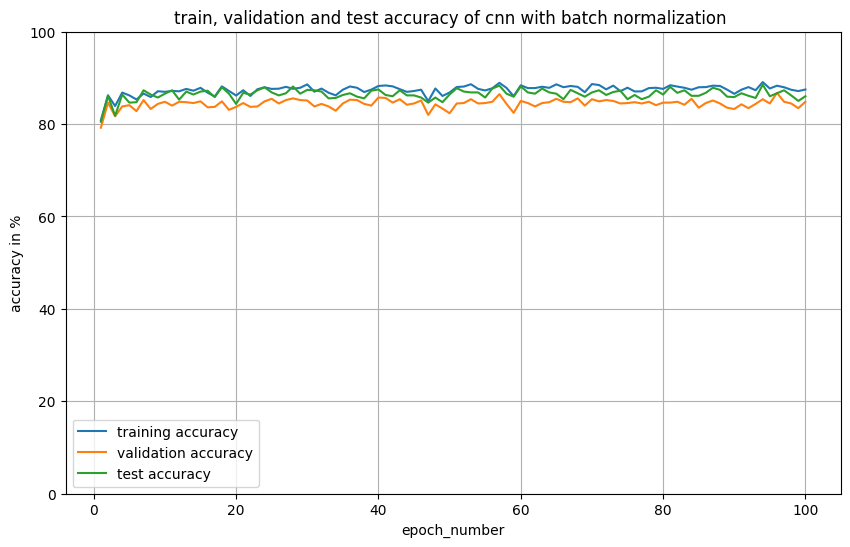

In [12]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN with batch
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy mobilenet-v2 and 3 layer ')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

In [13]:
# Define the model and optimizer
model = models.mobilenet_v2(pretrained=True)

num_params = len(list(model.parameters()))

for i, param in enumerate(model.parameters()):
    if i < num_params - 6:
        param.requires_grad = False


in_features = model.classifier[-1].in_features
num_classes = 10
model.classifier[-1] = nn.Linear(in_features, num_classes)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

criterion = nn.CrossEntropyLoss()

epochs = 100

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    model = model.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = model(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    model = model.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = model(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    model = model.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')


Starting Epoch: 1...
Loss: 0.779
Train Accuracy = 86.729%
Validation Accuracy = 84.899%
Test Accuracy = 86.372%
Starting Epoch: 2...
Loss: 0.609
Train Accuracy = 88.547%
Validation Accuracy = 86.372%
Test Accuracy = 86.924%
Starting Epoch: 3...
Loss: 0.556
Train Accuracy = 86.499%
Validation Accuracy = 83.794%
Test Accuracy = 85.175%
Starting Epoch: 4...
Loss: 0.531
Train Accuracy = 88.939%
Validation Accuracy = 86.280%
Test Accuracy = 88.766%
Starting Epoch: 5...
Loss: 0.515
Train Accuracy = 89.250%
Validation Accuracy = 85.635%
Test Accuracy = 86.924%
Starting Epoch: 6...
Loss: 0.496
Train Accuracy = 89.871%
Validation Accuracy = 87.569%
Test Accuracy = 89.963%
Starting Epoch: 7...
Loss: 0.469
Train Accuracy = 90.838%
Validation Accuracy = 85.635%
Test Accuracy = 88.674%
Starting Epoch: 8...
Loss: 0.474
Train Accuracy = 90.953%
Validation Accuracy = 87.937%
Test Accuracy = 89.963%
Starting Epoch: 9...
Loss: 0.445
Train Accuracy = 91.356%
Validation Accuracy = 88.122%
Test Accuracy = 

Text(0.5, 1.0, 'train, validation and test accuracy of cnn with batch normalization ')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

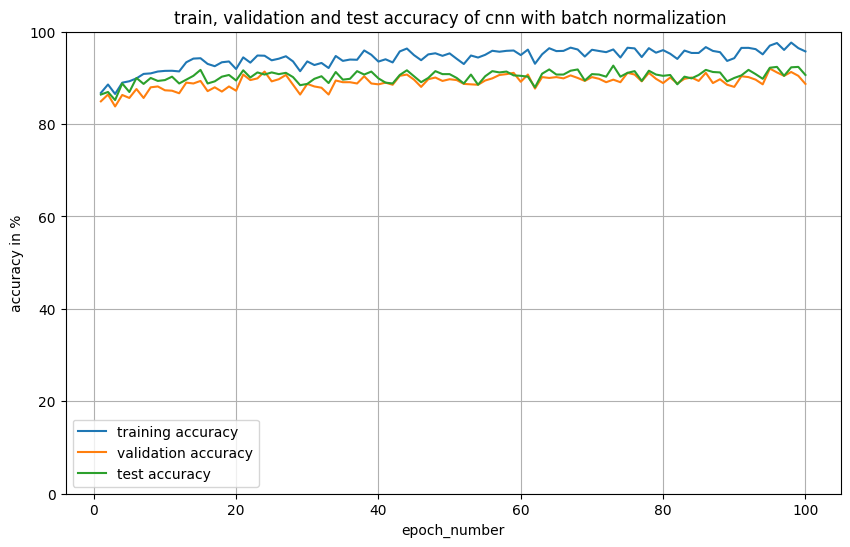

In [14]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN with batch
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy for mobilenet-v2 and 6 layer ')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

In [15]:
# Define the model and optimizer
model = models.mobilenet_v2(pretrained=True)

num_params = len(list(model.parameters()))

for i, param in enumerate(model.parameters()):
    if i < num_params - 9:
        param.requires_grad = False


in_features = model.classifier[-1].in_features
num_classes = 10
model.classifier[-1] = nn.Linear(in_features, num_classes)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

criterion = nn.CrossEntropyLoss()

epochs = 100

epoch_log_01 = []
loss_log_01 = []
train_accuracy_log_01 = []
test_accuracy_log_01 = []
validation_accuracy_log_01 = []


for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    model = model.train()

    for i, data in enumerate(trainloader):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = model(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 
    model = model.eval()
    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)
            

            outputs = model(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 
    model = model.eval()
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')

    epoch_log_01.append(epoch_num)
    loss_log_01.append(actual_loss)
    train_accuracy_log_01.append(train_accuracy)
    validation_accuracy_log_01.append(validation_accuracy)
    test_accuracy_log_01.append(test_accuracy)

print('Finished Training')


Starting Epoch: 1...
Loss: 0.745
Train Accuracy = 84.381%
Validation Accuracy = 82.781%
Test Accuracy = 84.899%
Starting Epoch: 2...
Loss: 0.550
Train Accuracy = 86.234%
Validation Accuracy = 83.978%
Test Accuracy = 85.543%
Starting Epoch: 3...
Loss: 0.529
Train Accuracy = 88.524%
Validation Accuracy = 86.556%
Test Accuracy = 88.029%
Starting Epoch: 4...
Loss: 0.487
Train Accuracy = 86.441%
Validation Accuracy = 84.622%
Test Accuracy = 88.122%
Starting Epoch: 5...
Loss: 0.450
Train Accuracy = 86.303%
Validation Accuracy = 84.530%
Test Accuracy = 86.372%
Starting Epoch: 6...
Loss: 0.455
Train Accuracy = 88.421%
Validation Accuracy = 84.899%
Test Accuracy = 88.214%
Starting Epoch: 7...
Loss: 0.441
Train Accuracy = 86.878%
Validation Accuracy = 84.070%
Test Accuracy = 86.004%
Starting Epoch: 8...
Loss: 0.424
Train Accuracy = 90.631%
Validation Accuracy = 87.753%
Test Accuracy = 89.687%
Starting Epoch: 9...
Loss: 0.421
Train Accuracy = 89.227%
Validation Accuracy = 86.280%
Test Accuracy = 

Text(0.5, 1.0, 'train, validation and test accuracy for mobilenet-v2 and 9 layer ')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

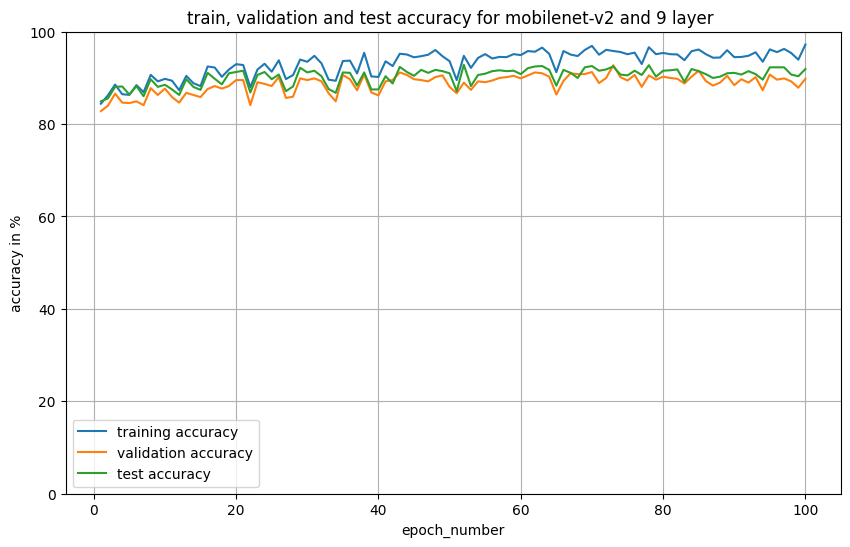

In [16]:
import matplotlib.pyplot as plt

#plotting train, validation and test accuracies for ParametricCNN with batch
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_01, train_accuracy_log_01, label='training accuracy')
ax.plot(epoch_log_01, validation_accuracy_log_01, label='validation accuracy')
ax.plot(epoch_log_01, test_accuracy_log_01, label='test accuracy')

ax.set_title('train, validation and test accuracy for mobilenet-v2 and 9 layer ')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()